In [1]:
import scanpy as sc
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import issparse

import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import pearsonr
import scipy


In [46]:
"""adata1 = sc.read('validation/diff_gene/stagei/Lung_Cancer_HD_Only_Experiment1T_cell.h5ad')
adata2 = sc.read('validation/diff_gene/stagei/Breast_Cancer_FreshT_cell.h5ad')
adata3 = sc.read('validation/diff_gene/stagei/Colon_Cancer_P1T_cell.h5ad')
adata4 = sc.read('validation/diff_gene/stagei/Colon_Cancer_P2T_cell.h5ad')
adata5 = sc.read('validation/diff_gene/stagei/Colon_Cancer_P5T_cell.h5ad')
adata6 = sc.read('validation/diff_gene/stagei/HumanLungCancerT_cell.h5ad')
adata7 = sc.read('validation/diff_gene/stagei/Lung_Cancer_Fixed_FrozenT_cell.h5ad')

adatas = [adata1, adata2, adata3, adata4, adata5, adata6, adata7]
adata = sc.concat(adatas, join='inner', axis=0) """

/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
adata = sc.read('validation/diff_gene/stagei/Lung_Cancer_HD_Only_Experiment1T_cell.h5ad')

In [4]:
diff_gene = pd.read_csv('validation/diff_gene/all_data_diff_gene_markers_top5000_filtered.csv')['gene'].tolist()

In [5]:
diff_gene_filtered = [gene for gene in diff_gene if gene in adata.var_names]
diff_gene_filtered

['MSLN',
 'SLC34A2',
 'CARTPT',
 'CD24',
 'MX1',
 'SPP1',
 'CHGA',
 'NKG7',
 'LTF',
 'FAM118A',
 'SDS',
 'EPYC',
 'ACAP1',
 'HNRNPLL',
 'IDH2',
 'CLU',
 'NKD2',
 'SCG2',
 'COPE',
 'CCR2',
 'MMP13',
 'ISG15',
 'CCL18',
 'GRB7',
 'QPRT',
 'MUCL1',
 'IL2RB',
 'RGS2',
 'DNAJB1',
 'SPTAN1',
 'HNRNPU',
 'CMPK2',
 'NFATC2',
 'EGFL6',
 'IGLC1',
 'MMP12',
 'ATF3',
 'PLCG1',
 'FTH1',
 'PPP1R15A',
 'CXCL14',
 'SRGN',
 'PLEC',
 'S100A6',
 'CFD',
 'IFI16',
 'NCL',
 'RGS1',
 'BEX3',
 'CD3G',
 'IDS',
 'TFRC',
 'DUSP2',
 'NOTCH1',
 'SOCS6',
 'TMC8',
 'SOCS3',
 'TNC',
 'PYHIN1',
 'FOS',
 'NR4A1',
 'FASN',
 'DERL3',
 'ST8SIA4',
 'FBXO7',
 'STAT2',
 'STAT5B',
 'DUSP1',
 'IL32',
 'COMP',
 'KAT6A',
 'ST5',
 'JAK1',
 'DDX58',
 'SLC5A6',
 'EPPK1',
 'KLRB1',
 'TMEM173',
 'CXCL9',
 'ADIRF',
 'ANKLE1',
 'S100A16',
 'S100A13',
 'AQP1',
 'PSMB4',
 'OAS1',
 'ARL4C',
 'XBP1',
 'IFI27',
 'MAP7',
 'F3',
 'PPP1R1B',
 'STAT1',
 'STAG2',
 'CTSD',
 'DIO2',
 'SERHL2',
 'OAS2',
 'TMED7',
 'PLAAT4',
 'RASSF5',
 'OLR1',
 'GA

In [6]:
adata_diff = adata[:, diff_gene_filtered]

In [7]:
gene_expression = adata_diff.to_df()


In [ ]:
correlation_matrix = gene_expression.corr(method='pearson')


In [ ]:
threshold = 0.7

# Build graph
G = nx.Graph()
for i, gene1 in enumerate(correlation_matrix.index):
    for j, gene2 in enumerate(correlation_matrix.columns):
        if i < j and correlation_matrix.loc[gene1, gene2] > threshold:
            G.add_edge(gene1, gene2, weight=correlation_matrix.loc[gene1, gene2])

In [ ]:
# Convert adjacency matrix for clustering
adj_matrix = nx.to_numpy_array(G)
gene_names = list(G.nodes)

# Hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0.5, affinity='precomputed', linkage='average')
labels = clustering.fit_predict(1 - np.abs(correlation_matrix.loc[gene_names, gene_names]))

# Assign labels to genes
modules = pd.DataFrame({'gene': gene_names, 'module': labels})
print(modules)

In [ ]:
import matplotlib.pyplot as plt

# Assign colors to modules
color_map = [labels[gene_names.index(node)] for node in G.nodes]

# Plot network
plt.figure(figsize=(12, 12))
nx.draw_networkx(G, node_color=color_map, with_labels=False, node_size=50, cmap='tab20')
plt.show()

In [ ]:
diff_gene_filtered = [gene for gene in diff_gene if gene in adata.var_names]
diff_gene_filtered

['MSLN',
 'SLC34A2',
 'CARTPT',
 'CD24',
 'MX1',
 'SPP1',
 'CHGA',
 'NKG7',
 'LTF',
 'FAM118A',
 'SDS',
 'EPYC',
 'ACAP1',
 'HNRNPLL',
 'IDH2',
 'CLU',
 'NKD2',
 'SCG2',
 'COPE',
 'CCR2',
 'MMP13',
 'ISG15',
 'CCL18',
 'GRB7',
 'QPRT',
 'MUCL1',
 'IL2RB',
 'RGS2',
 'DNAJB1',
 'SPTAN1',
 'HNRNPU',
 'CMPK2',
 'NFATC2',
 'EGFL6',
 'IGLC1',
 'MMP12',
 'ATF3',
 'PLCG1',
 'FTH1',
 'PPP1R15A',
 'CXCL14',
 'SRGN',
 'PLEC',
 'S100A6',
 'CFD',
 'IFI16',
 'NCL',
 'RGS1',
 'BEX3',
 'CD3G',
 'IDS',
 'TFRC',
 'DUSP2',
 'NOTCH1',
 'SOCS6',
 'TMC8',
 'SOCS3',
 'TNC',
 'PYHIN1',
 'FOS',
 'NR4A1',
 'FASN',
 'DERL3',
 'ST8SIA4',
 'FBXO7',
 'STAT2',
 'STAT5B',
 'DUSP1',
 'IL32',
 'COMP',
 'KAT6A',
 'ST5',
 'JAK1',
 'DDX58',
 'SLC5A6',
 'EPPK1',
 'KLRB1',
 'TMEM173',
 'CXCL9',
 'ADIRF',
 'ANKLE1',
 'S100A16',
 'S100A13',
 'AQP1',
 'PSMB4',
 'OAS1',
 'ARL4C',
 'XBP1',
 'IFI27',
 'MAP7',
 'F3',
 'PPP1R1B',
 'STAT1',
 'STAG2',
 'CTSD',
 'DIO2',
 'SERHL2',
 'OAS2',
 'TMED7',
 'PLAAT4',
 'RASSF5',
 'OLR1',
 'GA

In [ ]:
adata_diff = adata[:, diff_gene_filtered]

In [41]:
adata = sc.read('validation/diff_gene/stagei/Breast_Cancer_FreshT_cell.h5ad')

In [47]:
diff_gene = pd.read_csv('validation/diff_gene/all_data_diff_gene_markers_top5000_filtered.csv')['gene'].tolist()

In [48]:
diff_gene_filtered = [gene for gene in diff_gene if gene in adata.var_names]

In [49]:
adata_diff = adata[:, diff_gene_filtered]

In [51]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

def determine_gene_module_associations(adata, n_modules=10):
    """
    Determine gene module associations using dimensionality reduction and correlation analysis
    for all genes in the dataset.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data matrix with filtered genes
    n_modules : int, optional
        Number of modules to identify (default: 10)
    
    Returns:
    --------
    module_associations : pd.DataFrame
        DataFrame with gene module associations and correlation metrics for all genes
    """
    # Perform dimensionality reduction (PCA)
    sc.tl.pca(adata, n_comps=n_modules)
    
    # Extract principal components
    pc_matrix = adata.obsm['X_pca']
    gene_matrix = adata.X.toarray()
    
    # Initialize results storage
    module_associations = []
    
    # Calculate gene-module associations
    for i in range(n_modules):
        pc = pc_matrix[:, i]
        
        # Calculate correlation for each gene with the principal component
        gene_correlations = [pearsonr(pc, gene_matrix[:, j])[0] for j in range(gene_matrix.shape[1])]
        
        # Get all genes and their correlations
        genes = adata.var_names
        
        # Create DataFrame with all genes and their correlations
        module_info = pd.DataFrame({
            'Gene': genes,
            f'PC{i+1}_Correlation': gene_correlations
        })
        
        # Sort by absolute correlation value (optional, helps with visualization)
        module_info = module_info.assign(
            abs_correlation=module_info[f'PC{i+1}_Correlation'].abs()
        ).sort_values('abs_correlation', ascending=False).drop('abs_correlation', axis=1)
        
        module_info['Module'] = f'Module_{i+1}'
        module_associations.append(module_info)
    
    # Combine all module associations
    final_associations = pd.concat(module_associations, ignore_index=True)
    
    return final_associations

# Apply the function
module_associations = determine_gene_module_associations(adata_diff)

# Save results
module_associations.to_csv('all_module.csv', index=False)

# Display first few rows of associations
print("First few rows of the associations:")
print(module_associations.head())

# Display summary statistics
print("\nSummary statistics:")
print(module_associations.describe())

# Display number of genes per module
print("\nNumber of genes per module:")
print(module_associations.groupby('Module').size())

First few rows of the associations:
    Gene  PC1_Correlation    Module  PC2_Correlation  PC3_Correlation  \
0  MUCL1         0.811333  Module_1              NaN              NaN   
1   APOD         0.796713  Module_1              NaN              NaN   
2   FASN         0.773105  Module_1              NaN              NaN   
3   CD24         0.769665  Module_1              NaN              NaN   
4    PIP         0.756894  Module_1              NaN              NaN   

   PC4_Correlation  PC5_Correlation  PC6_Correlation  PC7_Correlation  \
0              NaN              NaN              NaN              NaN   
1              NaN              NaN              NaN              NaN   
2              NaN              NaN              NaN              NaN   
3              NaN              NaN              NaN              NaN   
4              NaN              NaN              NaN              NaN   

   PC8_Correlation  PC9_Correlation  PC10_Correlation  
0              NaN            

In [29]:
expression_data = adata_diff.X


In [30]:
expression_data = expression_data.toarray() if isinstance(expression_data, scipy.sparse.csr_matrix) else expression_data


In [31]:
gene_names = adata_diff.var_names


In [32]:
expression_df = pd.DataFrame(expression_data, columns=gene_names)


In [33]:
expression_df

,MSLN,SLC34A2,CARTPT,CD24,MX1,SPP1,CHGA,NKG7,LTF,FAM118A,...,CNOT2,ATP1B1,MARK3,RNF19B,RERE,CTSA,USP10,CYTH2,YIPF5,RIN2
0,0.0,0.0,0.0,3.264126,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,3.264126,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,3.926936,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,3.119940,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.119940,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,3.613646,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.613646,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
212,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,3.565702,0.000000,3.565702,3.565702,0.0,0.0,0.0,0.0
213,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
214,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,3.705799,0.000000,0.000000,0.0,0.0,0.0,0.0


In [24]:
expression_df.to_csv('Colon_Cancer_P1T_cell.csv', index=False)

In [180]:
import PyWGCNA

In [34]:
geneExp = 'Breast_Cancer_FreshT_cell.csv'


In [35]:
pyWGCNA_5xFAD = PyWGCNA.WGCNA(name='5xFAD', 
                              species='human', 
                              geneExpPath=geneExp, 
                              outputPath='',
                              save=True)
pyWGCNA_5xFAD.geneExpr.to_df().head(5)

NameError: name 'PyWGCNA' is not defined

In [ ]:
pyWGCNA_5xFAD.preprocess()


Pre-processing...
	Detecting genes and samples with too many missing values...


Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  4910
    Power  SFT.R.sq     slope truncated R.sq   mean(k)  median(k)      max(k)
0       1  0.175183 -1.941668       0.719396  54.40264  52.916212  139.119955
1       2  0.974933 -4.221032       0.973209  2.121761   1.938976    14.80994
2       3  0.506233 -3.914135       0.403091  0.116044   0.094551    2.431717
3       4  0.421606  -3.32971       0.295541  0.008662   0.005656    0.542435
4       5  0.406138  -2.58036       0.295419  0.000927   0.000396     0.14749
5       6  0.395371 -2.149617       0.291862  0.000148   0.000031    0.045287
6       7  0.390973 -1.900257       0.301023  0.000033   0.000003    0.014994
7       8  0.401141 -1.793265       0.363662  0.000009        0.0    0.005214
8       9  0.400369 -1.694478       0.366998  0.000003        0.0    0.001875
9      10  0.321122 -1.695242       0.134021  0.000001        0.0    0.000691
10     11  0.403241 -1.828717       0.3

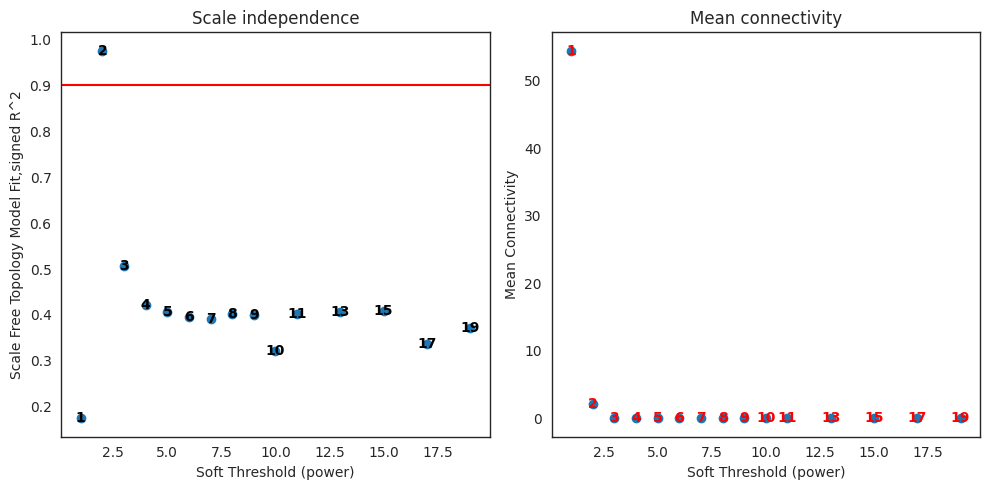

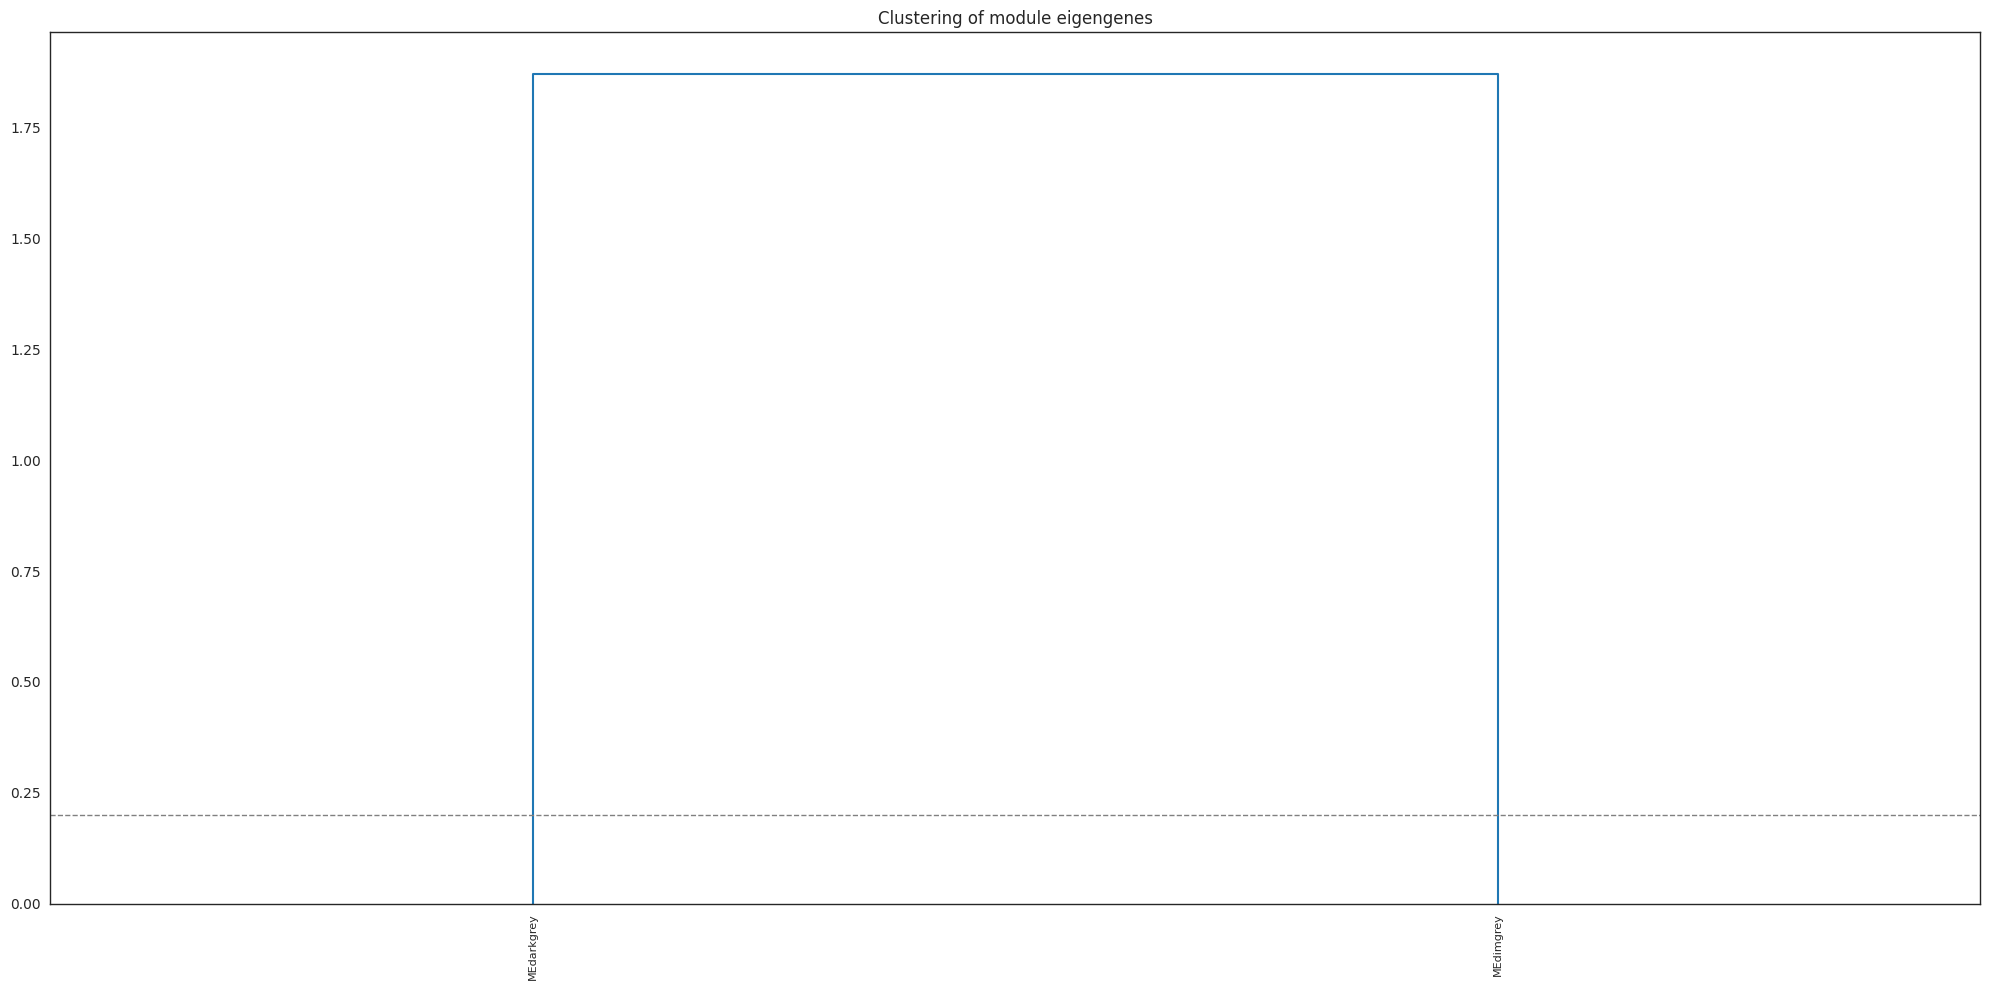

In [163]:
pyWGCNA_5xFAD.findModules()

Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  4910
    Power  SFT.R.sq     slope truncated R.sq   mean(k)  median(k)      max(k)
0       1  0.175183 -1.941668       0.719396  54.40264  52.916212  139.119955
1       2  0.974933 -4.221032       0.973209  2.121761   1.938976    14.80994
2       3  0.506233 -3.914135       0.403091  0.116044   0.094551    2.431717
3       4  0.421606  -3.32971       0.295541  0.008662   0.005656    0.542435
4       5  0.406138  -2.58036       0.295419  0.000927   0.000396     0.14749
5       6  0.395371 -2.149617       0.291862  0.000148   0.000031    0.045287
6       7  0.390973 -1.900257       0.301023  0.000033   0.000003    0.014994
7       8  0.401141 -1.793265       0.363662  0.000009        0.0    0.005214
8       9  0.400369 -1.694478       0.366998  0.000003        0.0    0.001875
9      10  0.3

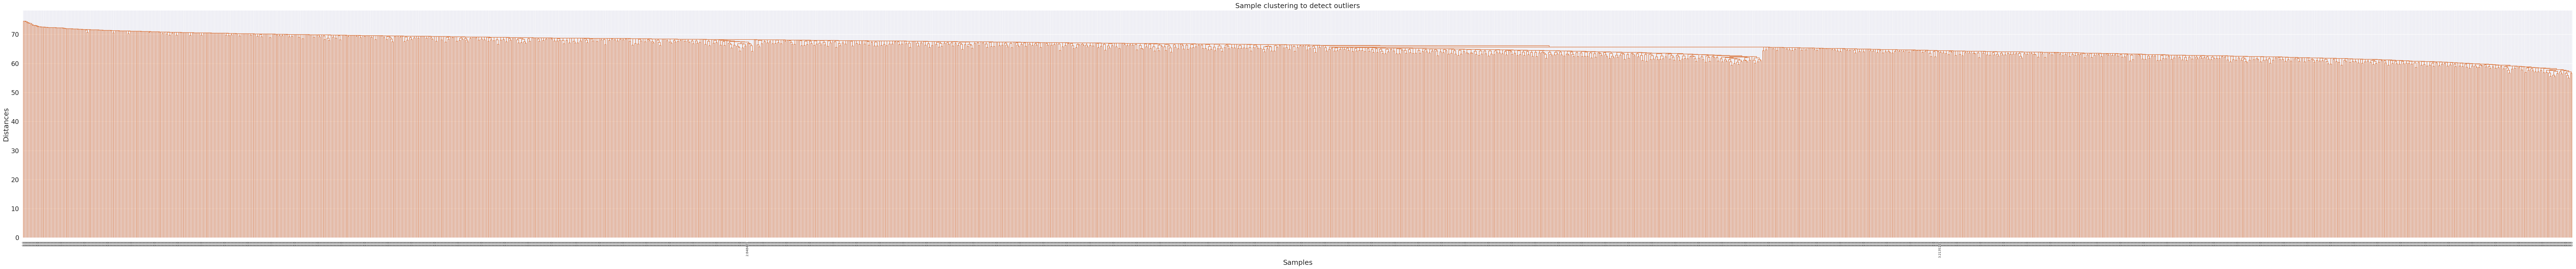

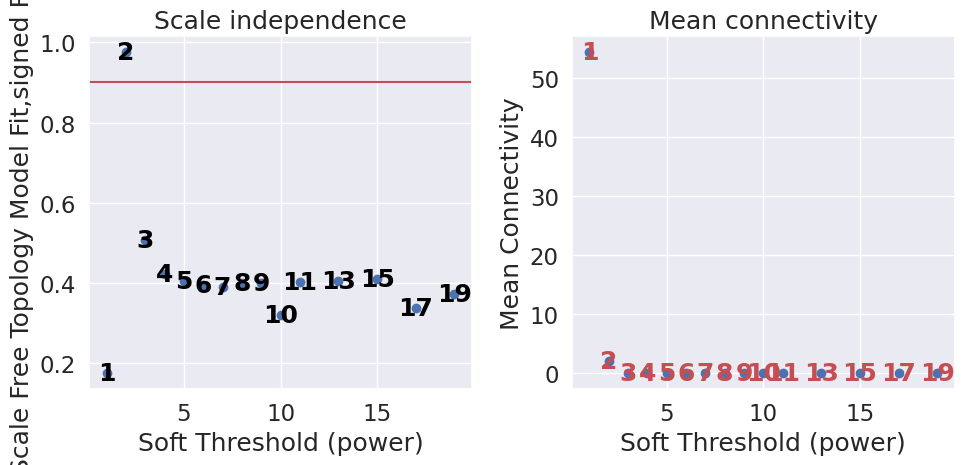

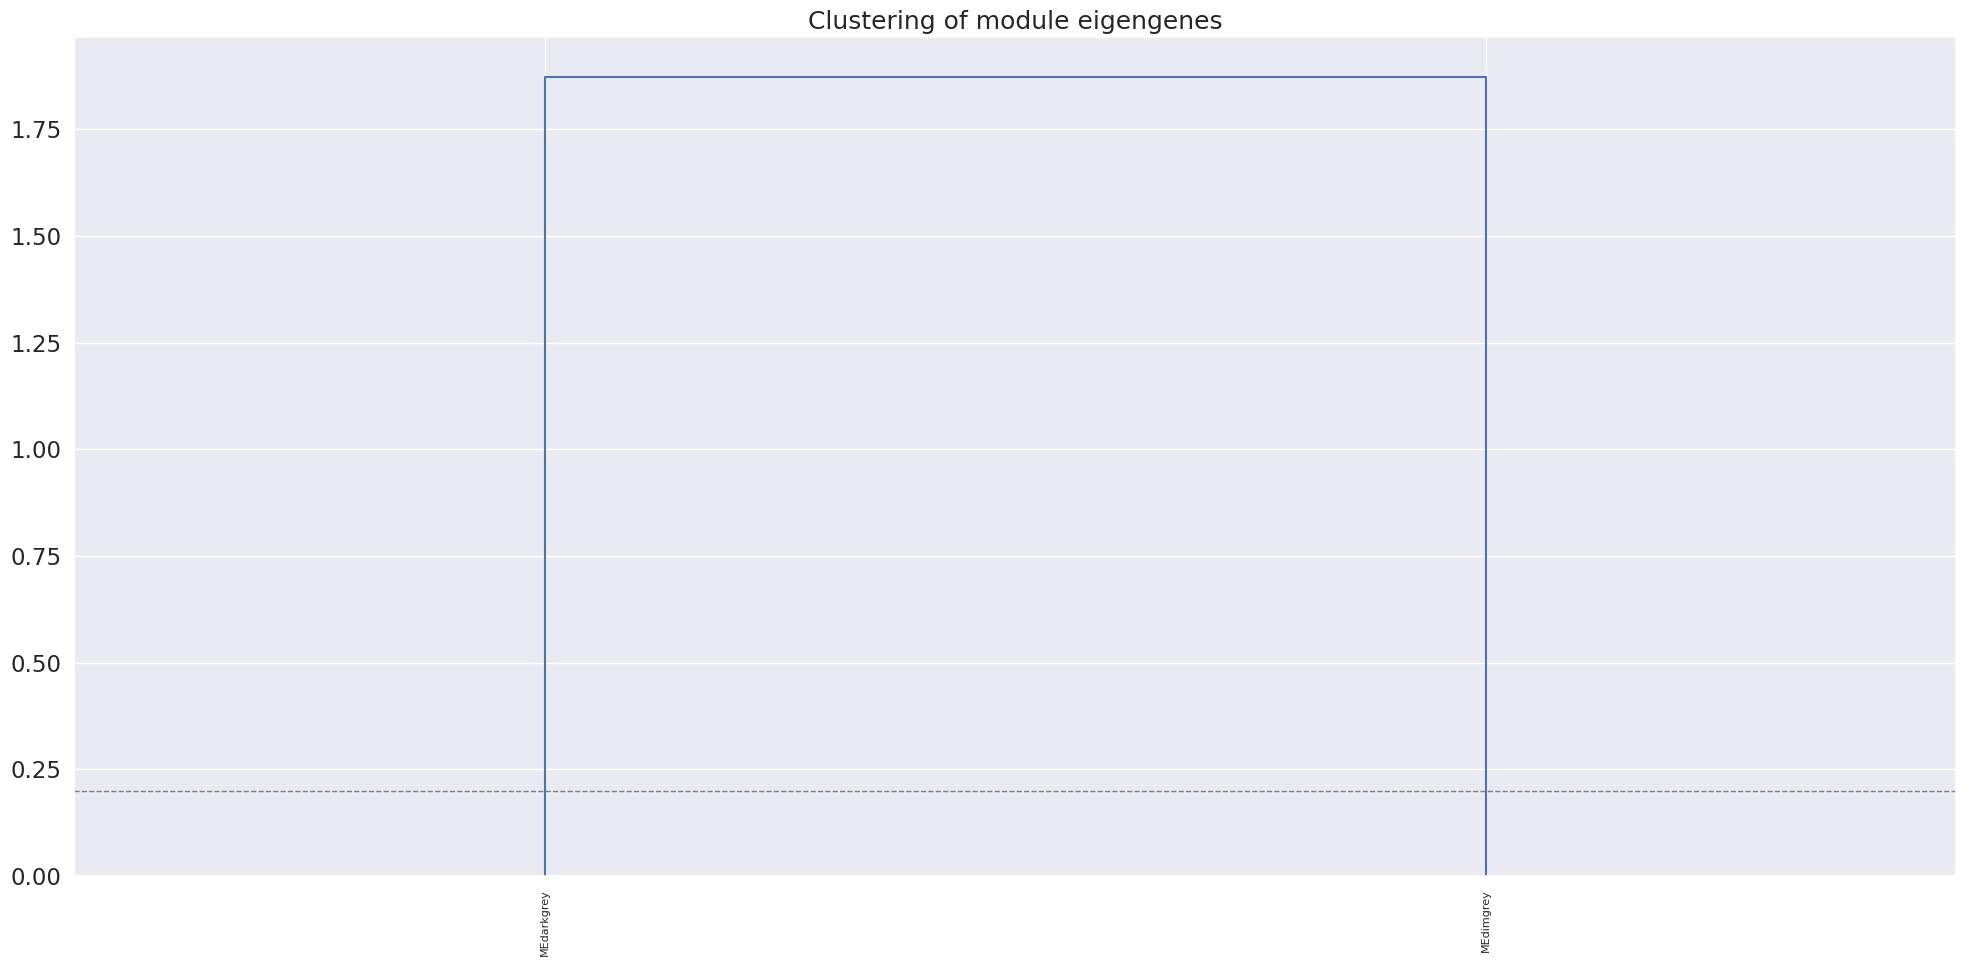

In [167]:
# Ensure that the aspect ratio values are positive
pyWGCNA_5xFAD.runWGCNA()

In [169]:
pyWGCNA_5xFAD.top_n_hub_genes(n=10)


TypeError: top_n_hub_genes() missing 1 required positional argument: 'moduleName'